In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

import jax
from jax import vmap
import jax.numpy as jnp
import jax.random as random

import numpyro
from numpyro import handlers
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import time
import os

/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Experimental setup
- BNN with shape [2, 32, 32, 1]
- 30x30 training-test points

Code from [NumPyro's Bayesian Neural Network example](https://num.pyro.ai/en/stable/examples/bnn.html)

In [2]:
def model(X, Y, D_H, D_Y=1):
    N, D_X = X.shape

    # sample first layer (we put unit normal priors on all weights)
    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((D_X, D_H)), jnp.ones((D_X, D_H))))
    assert w1.shape == (D_X, D_H)
    # z1 = jax.nn.relu(jnp.matmul(X, w1))  # <= first layer of activations
    z1 = jnp.tanh(jnp.matmul(X, w1))  # <= first layer of activations
    assert z1.shape == (N, D_H)

    # sample second layer
    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H))))
    assert w2.shape == (D_H, D_H)
    z2 = jax.nn.relu(jnp.matmul(z1, w2))  # <= second layer of activations
    assert z2.shape == (N, D_H)

    # sample third layer
    w3 = numpyro.sample("w3", dist.Normal(jnp.zeros((D_H, D_H)), jnp.ones((D_H, D_H))))
    assert w3.shape == (D_H, D_H)
    z3 = jax.nn.relu(jnp.matmul(z2, w3))  # <= second layer of activations
    assert z3.shape == (N, D_H)

    # sample final layer of weights and neural network output
    w4 = numpyro.sample("w4", dist.Normal(jnp.zeros((D_H, D_Y)), jnp.ones((D_H, D_Y))))
    assert w4.shape == (D_H, D_Y)
    z4 = jnp.matmul(z3, w4)  # <= output of the neural network
    assert z4.shape == (N, D_Y)

    if Y is not None:
        assert z4.shape == Y.shape

    # we put a prior on the observation noise
    prec_obs = numpyro.sample("prec_obs", dist.Gamma(3.0, 1.0))
    sigma_obs = 1.0 / jnp.sqrt(prec_obs)
    # sigma_obs = 1.0

    # observe data
    with numpyro.plate("data", N):
        # note we use to_event(1) because each observation has shape (1,)
        numpyro.sample("Y", dist.Normal(z4, sigma_obs).to_event(1), obs=Y)

def run_inference(model, args, rng_key, X, Y, D_H):
    start = time.time()
    kernel = NUTS(model)
    mcmc = MCMC(
        kernel,
        num_warmup=args["warmup"],
        num_samples=args["samples"],
        num_chains=args["chains"],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, X, Y, D_H)
    mcmc.print_summary()
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc.get_samples()


# helper function for prediction
def predict(model, rng_key, samples, X, D_H):
    model = handlers.substitute(handlers.seed(model, rng_key), samples)
    # note that Y will be sampled in the model because we pass Y=None here
    model_trace = handlers.trace(model).get_trace(X=X, Y=None, D_H=D_H)
    return model_trace["Y"]["value"]

In [3]:
from gpkanmodel.test_functions import goldstein_price
f = lambda x, y: goldstein_price(x, y) 

samples = 30
x1, x2 = jnp.meshgrid(jnp.linspace(-2, 2, samples), jnp.linspace(-2 , 2, samples))
X = jnp.stack([x1.flatten(), x2.flatten()]).T
y = jnp.log(f(X[:, 0], X[:, 1]).reshape(-1, 1))

In [4]:
rng_key, rng_key_predict = random.split(random.PRNGKey(0))
n_samples = 2000
args = {"warmup": int(n_samples * 0.1),
        "samples": n_samples,
        "chains": 1,
        }
num_hidden = 32
samples = run_inference(model, args, X=X, Y=y, D_H=num_hidden, rng_key=rng_key)

vmap_args = (
        samples,
        random.split(rng_key_predict, args["samples"] * args["chains"]),
    )

predictions_1 = vmap(
        lambda samples, rng_key: predict(model, rng_key, samples, X, num_hidden)
    )(*vmap_args)
predictions = predictions_1[..., 0]

mean_prediction = jnp.mean(predictions, axis=0)
percentiles = np.percentile(predictions, [5.0, 95.0], axis=0)

sample: 100%|██████████| 2200/2200 [08:34<00:00,  4.27it/s, 1023 steps of size 5.52e-04. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  prec_obs    227.97     33.07    234.05    164.80    275.96      4.79      1.51
   w1[0,0]      0.85      0.06      0.85      0.78      0.96     13.85      1.23
   w1[0,1]     -0.59      0.23     -0.64     -0.91     -0.26      3.13      2.03
   w1[0,2]      1.94      0.40      1.92      1.28      2.46      2.86      3.18
   w1[0,3]      0.67      0.05      0.67      0.61      0.74     20.53      1.12
   w1[0,4]     -0.80      0.15     -0.79     -1.04     -0.57      3.29      2.19
   w1[0,5]      2.30      0.23      2.32      1.86      2.61      4.14      1.90
   w1[0,6]      0.60      0.08      0.61      0.47      0.73      6.18      1.03
   w1[0,7]     -2.15      0.46     -2.02     -2.87     -1.56      3.02      2.65
   w1[0,8]      2.28      0.54      2.35      1.31      2.93      3.08      2.12
   w1[0,9]      1.70      0.20      1.71      1.36      2.02      9.34      1.00
  w1[0,10]      1.42      0

~8 mins runtime with [2, 32, 32, 1] BNN training on 900 total samples.

In [5]:
print(mean_prediction.shape)

(900,)


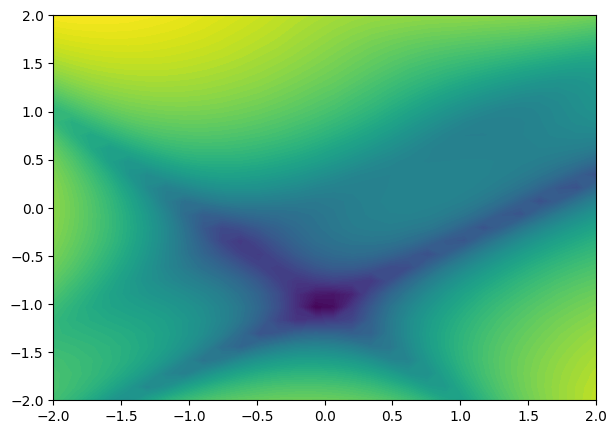

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(x1, x2, mean_prediction.reshape(30, 30), levels=100)
plt.show()

In [7]:
def mse(y, yhat):
    return jnp.sum((y - yhat )**2) / y.shape[0]
mse(y.flatten(), mean_prediction.flatten()) 

Array(0.0003682, dtype=float32)

In [8]:
print(jnp.min(mean_prediction), jnp.max(mean_prediction))

1.4682899 13.830936


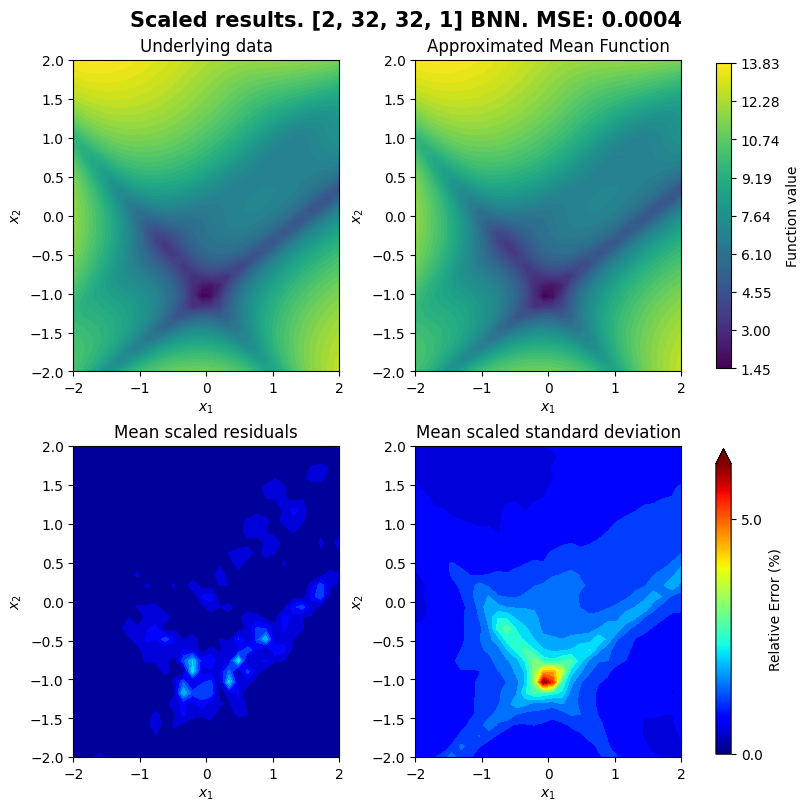

In [9]:
from plotting import plot_results_normalized, plot_results, plot_results_cv
fig, axs = plot_results_normalized(
    x1,
    x2,
    y=y,
    mu_hat=mean_prediction,
    sigma_hat=jnp.std(predictions, axis=0),
    title=f"Scaled results. [2, 32, 32, 1] BNN. MSE: {mse(y.flatten(), mean_prediction.flatten()):.4f}"
)
plt.savefig("result_plots/bnn_goldstein_scaled.png", dpi=100)
plt.show()

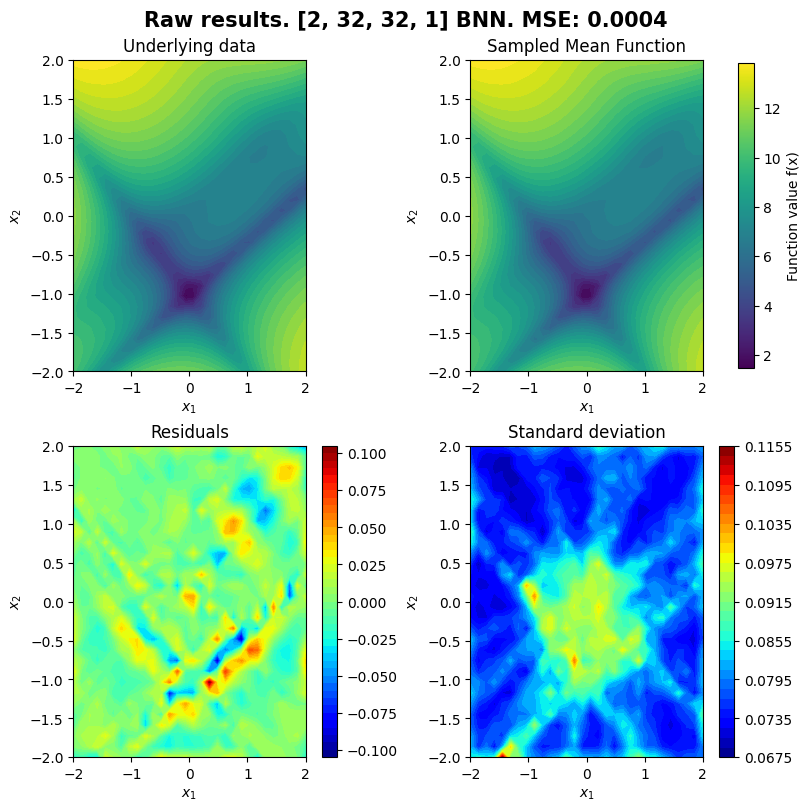

In [10]:
fig, axs = plot_results(
    x1,
    x2,
    y=y,
    mu_hat=mean_prediction,
    sigma_hat=jnp.std(predictions, axis=0),
    title=f"Raw results. [2, 32, 32, 1] BNN. MSE: {mse(y.flatten(), mean_prediction.flatten()):.4f}"
)
plt.savefig("result_plots/bnn_goldstein_raw.png", dpi=100)
plt.show()